<a href="https://colab.research.google.com/github/onyxs-prog/AI-ML-projects/blob/main/Text_Classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mini-Project Title: Building a Text Classification Model for News Categorization

## Overview
This project focuses on using Natural Language Processing (NLP) techniques to build a text classification model for news categorization. With a large influx of news articles daily, manual categorization is inefficient. Automating this process using NLP ensures scalability, accuracy, and consistency.


## Objective
Develop an NLP-powered machine learning model that categorizes news articles into predefined categories such as Politics, Sports, Technology, Entertainment, and Health. This project covers the complete NLP pipeline, including preprocessing, feature extraction, model training, evaluation, and deployment.

## Learning Outcomes
1. Understand text preprocessing techniques like tokenization, stopword removal, and stemming/lemmatization.
2. Explore feature extraction methods such as Bag of Words, TF-IDF, and word embeddings.
3. Learn to use NLP libraries like NLTK, spaCy, and Hugging Face Transformers.
4. Experiment with NLP-specific models such as LSTM, BERT, or other transformer-based models.
5. Gain experience in deploying NLP models via APIs.


## Step 1: Define the Problem
### Task:
Understand the problem and its real-world implications. Automation of news categorization using NLP can save time, improve accuracy, and enhance user experience by organizing content effectively.

### Mini-task:
Write a brief paragraph on how NLP benefits the media industry in automating news categorization.


## Step 2: Data Collection
### Task:
Collect a dataset of news articles suitable for text classification. Publicly available datasets such as the AG News dataset or datasets from Kaggle can be used.

### Mini-task:
Download and load a suitable dataset for NLP tasks.


I am using the kaggle AG news dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/archive.zip'
extracted_file_path = '/tmp/train.csv'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extract('train.csv', '/tmp/')

df= pd.read_csv(extracted_file_path)
df = pd.DataFrame(df)



In [ ]:
df.head(10)

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
5,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...
6,3,Money Funds Fell in Latest Week (AP),AP - Assets of the nation's retail money marke...
7,3,Fed minutes show dissent over inflation (USATO...,USATODAY.com - Retail sales bounced back a bit...
8,3,Safety Net (Forbes.com),Forbes.com - After earning a PH.D. in Sociolog...
9,3,Wall St. Bears Claw Back Into the Black,"NEW YORK (Reuters) - Short-sellers, Wall Stre..."


## Step 3: Exploratory Data Analysis (EDA)
### Task:
Analyze the dataset to understand the text structure, class distribution, and any potential imbalances.

### Mini-task:
Visualize the class distribution using a bar chart and inspect a few examples of text data.

Example

```python
import pandas as pd
import matplotlib.pyplot as plt

# Convert dataset to DataFrame for easier manipulation
df = pd.DataFrame(dataset['train'])
df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.show()

# Inspect a sample
print(df.head())
```

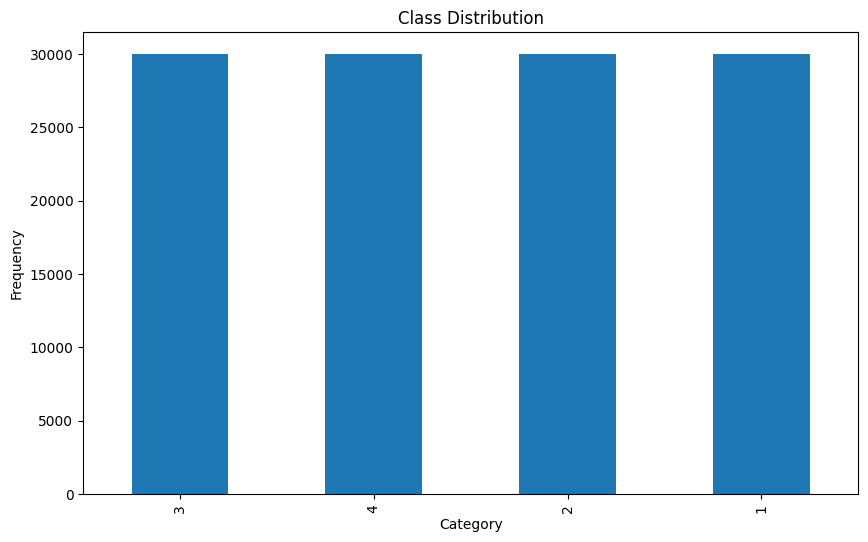

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df['Class Index'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.show()

The bar chart visualizing the 'Class Index' distribution in our data
provides a crucial insight into our dataset:
---


*   Balanced Dataset: As you can see, the heights of the bars for each 'Class Index' (1, 2, 3, and 4) are very similar. This means that the number of news articles in each category (Politics, Sports, Technology, Entertainment, or Health, depending on what each index represents in this dataset) is roughly equal.

*  Implications for Modeling: A balanced dataset is generally desirable for training classification models. When classes are heavily imbalanced (i.e., one class has significantly more examples than others), a model might become biased towards the majority class and perform poorly on the minority classes. Since our dataset is balanced, we can expect that a standard classification model will have a good chance of learning to predict all categories reasonably well without requiring special techniques to handle imbalance.





## Step 4: Text Preprocessing
### Task:
Preprocess the text data using techniques such as:
- Lowercasing
- Tokenization
- Stopword removal
- Lemmatization (optional)

### Mini-task:
Clean a small sample of the dataset using NLP libraries like NLTK or spaCy.

Example

```python
import spacy

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    return " ".join(tokens)

# Apply preprocessing
df['cleaned_text'] = df['text'].apply(preprocess)
print(df[['text', 'cleaned_text']].head())
```


In [ ]:

!pip install spacy


!python -m spacy download en_core_web_sm




     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 61.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
import spacy

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
  doc = nlp(text.lower())
  tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
  return " ".join(tokens)

# Combine 'Title' and 'Description' and apply preprocessing
df['cleaned_text'] = (df['Title'].astype(str) + ' ' + df['Description'].astype(str)).apply(preprocess)

# Display relevant columns to check preprocessing
print(df[['Title', 'Description', 'cleaned_text']].head())

                                               Title  \
0  Wall St. Bears Claw Back Into the Black (Reuters)   
1  Carlyle Looks Toward Commercial Aerospace (Reu...   
2    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3  Iraq Halts Oil Exports from Main Southern Pipe...   
4  Oil prices soar to all-time record, posing new...   

                                         Description  \
0  Reuters - Short-sellers, Wall Street's dwindli...   
1  Reuters - Private investment firm Carlyle Grou...   
2  Reuters - Soaring crude prices plus worries\ab...   
3  Reuters - Authorities have halted oil export\f...   
4  AFP - Tearaway world oil prices, toppling reco...   

                                        cleaned_text  
0  wall st bears claw black reuter reuter short s...  
1  carlyle look commercial aerospace reuter reute...  
2  oil economy cloud stock outlook reuters reuter...  
3  iraq halt oil export main southern pipeline re...  
4  oil price soar time record pose new menace eco..

In [ ]:
pd.DataFrame(df)

,Class Index,Title,Description,cleaned_text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",wall st bears claw black reuter reuter short s...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,carlyle look commercial aerospace reuter reute...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,oil economy cloud stock outlook reuters reuter...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,iraq halt oil export main southern pipeline re...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",oil price soar time record pose new menace eco...
...,...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...,pakistan musharraf say will quit army chief ...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...,renteria sign shelf deal red sox general manag...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...,saban go dolphin miami dolphin courtship lsu c...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...,today nfl games pittsburgh ny giants time 1:30...


### Step 5: Feature Engineering
### Task:
Convert the preprocessed text into numerical representations using:
- Bag of Words (BoW)
- Term Frequency-Inverse Document Frequency (TF-IDF)
- Pre-trained word embeddings (e.g., GloVe or FastText)

### Mini-task:
Compare the feature matrices generated using TF-IDF and embeddings.

Example

```python
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Representation
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df['cleaned_text'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
```

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df['cleaned_text'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (120000, 5000)


## Step 6: Model Training Using NLP Models
### Task:
Train a machine learning model using features derived from NLP techniques. You can use classical models like Logistic Regression or advanced models like LSTMs or transformers.

### Mini-task:
Train a simple logistic regression model on the TF-IDF features.

```python
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(tfidf_matrix, df['label'], test_size=0.2, random_state=42)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
```


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(tfidf_matrix, df['Class Index'], test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

accuracy = model.score(x_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 90.90%


### Optional: Fine-Tune a BERT Model
Train a transformer-based model using the Hugging Face `transformers` library for state-of-the-art results in text classification.

# Task
Create a transformer model for text classification using the "train.csv" dataset.

## Install necessary libraries

### Subtask:
Install the `transformers` and `datasets` libraries.


**Reasoning**:
Install the necessary libraries for working with transformers and datasets.



In [ ]:
!pip install transformers datasets

## Load a pre-trained model and tokenizer

### Subtask:
Choose a pre-trained transformer model (like BERT, RoBERTa, etc.) suitable for text classification and load its corresponding tokenizer.


**Reasoning**:
Import the necessary classes and load the tokenizer and model for a pre-trained transformer suitable for text classification.



In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_checkpoint = "bert-base-uncased"
num_labels = df['Class Index'].nunique()

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Prepare the dataset

### Subtask:
Tokenize the text data and format the dataset into a suitable format for the `transformers` library, likely using the `datasets` library. This may involve mapping the class labels to integers if they are not already.


**Reasoning**:
The first step is to create a Hugging Face Dataset object from the pandas DataFrame, mapping the required columns and then define and apply a tokenization function.



In [ ]:
from datasets import Dataset

# Create a Hugging Face Dataset object from the pandas DataFrame
dataset = Dataset.from_pandas(df[['cleaned_text', 'Class Index']].rename(columns={'cleaned_text': 'text', 'Class Index': 'label'}))

# Define the tokenization function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

# Apply the tokenization function to the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Split the tokenized dataset into training and testing sets
train_test_split_dataset = tokenized_datasets.train_test_split(test_size=0.2)

print(train_test_split_dataset)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 96000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 24000
    })
})


In [ ]:
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(1000))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(1000))

In [ ]:
from transformers import TrainingArguments
training_args = TrainingArguments(
   output_dir="./results",
   evaluation_strategy="epoch",
   learning_rate=2e-5,
   per_device_train_batch_size=8,
   num_train_epochs=3,
   weight_decay=0.01,
   push_to_hub=False,
)

In [ ]:
from transformers import Trainer
trainer = Trainer(
   model=model,
   args=training_args,
   train_dataset=small_train_dataset,
   eval_dataset=small_eval_dataset,
)
trainer.train()

In [ ]:
results = trainer.evaluate()
print(results)

In [ ]:
trainer.push_to_hub("my_model_name")